# __2- Model Training__ 

Install torch library

 <span style="color: red;"> RUN IT ONCE IF YOU FACED ERROR IN CELL 3</span>

In [ ]:
!pip install torch torchvision

  Using cached torch-2.10.0-cp311-cp311-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp311-cp311-win_amd64.whl.metadata (5.4 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached torch-2.10.0-cp311-cp311-win_amd64.whl (113.7 MB)
Using cached torchvision-0.25.0-cp311-cp311-win_amd64.whl (4.0 MB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\rahaf\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import torch
print(torch.__version__)


2.10.0+cpu


## 2.1 Normlization

In [3]:
import torch # pytorch main libirary
from torchvision import transforms # tp process images
from torch.utils.data import Dataset, DataLoader # Dataset to build a class for data , Dataloader to send data to the model as batches
from PIL import Image # to open images
import pandas as pd # to use train_df/val_df/test_df

transform = transforms.Compose([ # to make learning easier
    transforms.ToTensor(), # convert images from being in 0 to 255 to being 0 and 1
    transforms.Normalize( # this is ImageNet normlization
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

 Normliazation Equation = $$ \frac{x - mean}{std} = x_{normalized} $$

## 2.2 Dataset Class

 This class is needed to specify how to read images and how to return the image and its label.

In [4]:
class GestureDataset(Dataset):
    def __init__(self, dataframe, transform=None): # to store data & transformers
        self.dataframe = dataframe
        self.transform = transform

        self.label_map = { # Palm -> 0 , Fist -> 1
            "Palm": 0,
            "Fist": 1
        }

    def __len__(self): # Dataloader will use it to know the size of data
        return len(self.dataframe)

    def __getitem__(self, idx):                           # most importent function works like follows:
    
        img_path = self.dataframe.iloc[idx]["image_path"] # 1- take image path
        label = self.dataframe.iloc[idx]["label"]         # 2- open image

        image = Image.open(img_path).convert("RGB")       # 3- convert it to RGB

        if self.transform:                                # 4- apply transform
            image = self.transform(image)

        label = self.label_map[label]                     # 5- convert label to image

        return image, label                               # 6- return (image,label)


## 2.3 Creat Dataset for Each Split 

In [5]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

train_dataset = GestureDataset(train_df, transform=transform)
val_dataset = GestureDataset(val_df, transform=transform)
test_dataset = GestureDataset(test_df, transform=transform)

## 2.3 Creat DataLoder

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # every time pass 32 images
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 2.4 Model Prepatation

In [7]:
import torch.nn as nn
from torchvision import models

# Load Pretrained ResNet-18 Model
model = models.resnet18(pretrained=True)

# Modify the Final Fully Connected Layer where we have 2 classes 
num_classes = 2
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Loss, CrossEntropyLoss is suitable for multi-class classification
criterion = nn.CrossEntropyLoss()

# fraze all layers to make trainig faster "sutiable for mediam data size"
for param in model.parameters():
    param.requires_grad = False

# activite onlty last layer (Fully Connected Layer FC) to make predction
for param in model.fc.parameters():
    param.requires_grad = True

# Optimizerو # Adam provides adaptive learning rates for faster, stable training.

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-4)


C:\Users\rahaf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\rahaf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 2.5 Model Training

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # if the device has GPU use it, else use CPU
# model = model.to(device) 
# num_epochs = 10 # the num of times the model will go through the data
# for epoch in range(num_epochs):
    
#     model.train()   # put the model in training mode 
#     running_loss = 0.0
#     correct = 0
#     total = 0

#     for images, labels in train_loader: # repeat learning process until finish all images
        
#         images = images.to(device) # put labels and images in the same device
#         labels = labels.to(device)

#         optimizer.zero_grad() # make old valus = 0 every time 

#         # Forward Pass
#         outputs = model(images) # model recaive image, pass it through layers, give possibility

#         loss = criterion(outputs, labels) # calculate the diffrance between the prediction and the real value

#         # Backward Pass
#         loss.backward()

#         optimizer.step() # Adam updates the weights to reduce the loss

#         # حساب الإحصائيات
#         running_loss += loss.item()
#         _, predicted = torch.max(outputs, 1) # take highest prediction
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()

#     epoch_loss = running_loss / len(train_loader)
#     epoch_acc = 100 * correct / total

#     print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")


Epoch [1/10] Loss: 0.4249, Accuracy: 87.48%
Epoch [2/10] Loss: 0.2465, Accuracy: 95.92%
Epoch [3/10] Loss: 0.1814, Accuracy: 97.01%
Epoch [4/10] Loss: 0.1437, Accuracy: 97.40%
Epoch [5/10] Loss: 0.1225, Accuracy: 97.99%
Epoch [6/10] Loss: 0.1048, Accuracy: 98.29%
Epoch [7/10] Loss: 0.0938, Accuracy: 98.28%
Epoch [8/10] Loss: 0.0854, Accuracy: 98.41%
Epoch [9/10] Loss: 0.0767, Accuracy: 98.58%
Epoch [10/10] Loss: 0.0717, Accuracy: 98.64%


## The benefits of integrating Validation within Training:

- Monitor performance after each epoch.
- When to stop training (Early Stopping).
- See if the model is actually learning or overfitting.

Epoch [1/10] Train Loss: 0.0672, Train Acc: 98.66% | Val Loss: 0.0428, Val Acc: 99.57%
Epoch [2/10] Train Loss: 0.0609, Train Acc: 99.01% | Val Loss: 0.0402, Val Acc: 99.67%
Epoch [3/10] Train Loss: 0.0556, Train Acc: 99.07% | Val Loss: 0.0372, Val Acc: 99.67%
Epoch [4/10] Train Loss: 0.0536, Train Acc: 98.97% | Val Loss: 0.0349, Val Acc: 99.62%
Epoch [5/10] Train Loss: 0.0514, Train Acc: 99.06% | Val Loss: 0.0324, Val Acc: 99.62%
Epoch [6/10] Train Loss: 0.0479, Train Acc: 99.11% | Val Loss: 0.0297, Val Acc: 99.86%
Epoch [7/10] Train Loss: 0.0464, Train Acc: 99.09% | Val Loss: 0.0275, Val Acc: 99.86%
Epoch [8/10] Train Loss: 0.0424, Train Acc: 99.19% | Val Loss: 0.0297, Val Acc: 99.71%
Epoch [9/10] Train Loss: 0.0414, Train Acc: 99.28% | Val Loss: 0.0250, Val Acc: 99.67%
Epoch [10/10] Train Loss: 0.0356, Train Acc: 99.40% | Val Loss: 0.0210, Val Acc: 99.90%


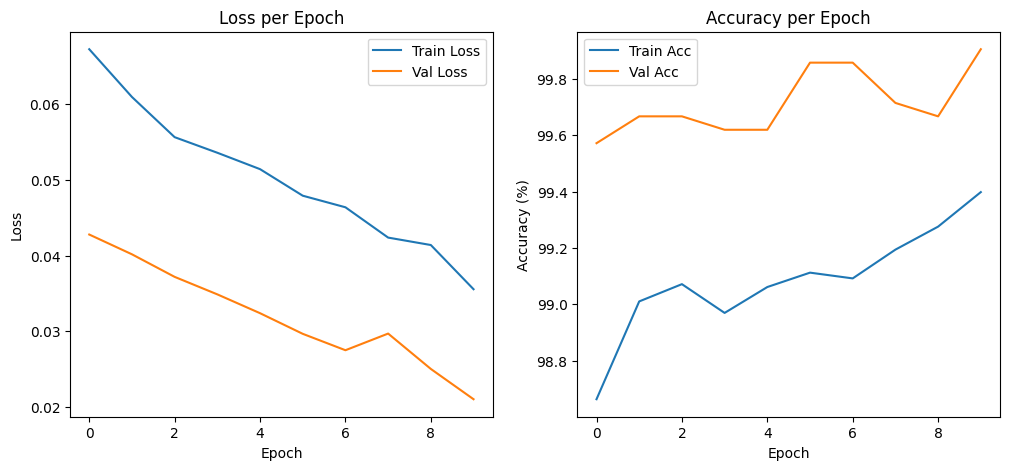

In [ ]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # if the device has GPU use it, else use CPU
model = model.to(device)

num_epochs = 10 # the num of times the model will go through the data

# used for comparision between each epoch
train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0

for epoch in range(num_epochs): 

    # training
    model.train() # put the model in training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader: # repeat learning process until finish all images
        images, labels = images.to(device), labels.to(device) # put labels and images in the same device
        optimizer.zero_grad() # make old values = 0 every time
         # Forward Pass
        outputs = model(images) # model recaive image, pass it through layers, give possibility
        loss = criterion(outputs, labels) # calculate the diffrance between the prediction and the real value
         # Backward Pass
        loss.backward() 
        optimizer.step() # Adam updates the weights to reduce the loss

        # حساب الإحصائيات
        running_loss += loss.item() 
        _, predicted = torch.max(outputs, 1) # take highest prediction
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # validation 
    model.eval() # put the model in validation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # to save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    # print result
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# draw graphs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per Epoch")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy per Epoch")

plt.show()


##### Trainig & validation results in : epoch = 10 , batch size = 32 , lr = 1e-4

###### Epoch [1/10] Train Loss: 0.0672, Train Acc: 98.66% | Val Loss: 0.0428, Val Acc: 99.57%
###### Epoch [2/10] Train Loss: 0.0609, Train Acc: 99.01% | Val Loss: 0.0402, Val Acc: 99.67%
###### Epoch [3/10] Train Loss: 0.0556, Train Acc: 99.07% | Val Loss: 0.0372, Val Acc: 99.67%
###### Epoch [4/10] Train Loss: 0.0536, Train Acc: 98.97% | Val Loss: 0.0349, Val Acc: 99.62%
###### Epoch [5/10] Train Loss: 0.0514, Train Acc: 99.06% | Val Loss: 0.0324, Val Acc: 99.62%
###### Epoch [6/10] Train Loss: 0.0479, Train Acc: 99.11% | Val Loss: 0.0297, Val Acc: 99.86%
###### Epoch [7/10] Train Loss: 0.0464, Train Acc: 99.09% | Val Loss: 0.0275, Val Acc: 99.86%
###### Epoch [8/10] Train Loss: 0.0424, Train Acc: 99.19% | Val Loss: 0.0297, Val Acc: 99.71%
###### Epoch [9/10] Train Loss: 0.0414, Train Acc: 99.28% | Val Loss: 0.0250, Val Acc: 99.67%
###### Epoch [10/10] Train Loss: 0.0356, Train Acc: 99.40% | Val Loss: 0.0210, Val Acc: 99.90%

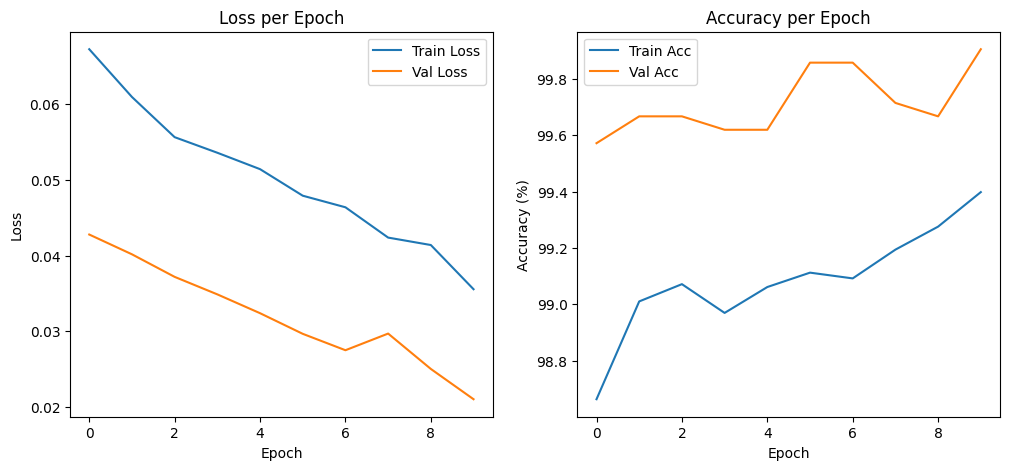

In [12]:
print(len(train_dataset.label_map))
print(train_dataset.label_map)

2
{'Palm': 0, 'Fist': 1}
